In [1]:
!pip install pyclustertend factor-analyzer mlxtend

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from pyclustertend import hopkins, vat
from mlxtend.frequent_patterns import apriori, association_rules
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

import warnings
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 707.1 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 12.7 MB/s eta 0:00:00
  Created wheel for factor-analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=83ba041c0a2a42a3f413ccd035bc19976d4ee16949c256d929956322ffd8cff7
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor-analyzer
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following depend


**1.1 Preprocesamiento del Dataset** Variables como `id`, `originalTitle`, `title`, `homePage`, `releaseDate`, `actorsCharacter`, `actors`, `director`, y las relacionadas a países productoras no aportan valor directo a los algoritmos de similitud métrica porque son identificadores, fechas o texto no estructurado. La variable `video` es un booleano que tiende a tener poca varianza. Por lo tanto, aislaremos las variables puramente numéricas para generar el clustering y trataremos los valores atípicos (outliers).



In [2]:
# Carga de datos
df = pd.read_csv('movies_2026.csv', encoding='latin1')

# Variables a descartar
cols_to_drop = [
    'id', 'originalTitle', 'title', 'homePage', 'video',
    'releaseDate', 'actorsCharacter', 'actors', 'director',
    'productionCompany', 'productionCompanyCountry', 'productionCountry',
    'actorsPopularity', 'originalLanguage', 'genres'
]

df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Llenar nulos con la mediana
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

# TRATAMIENTO DE OUTLIERS
for col in df_clean.columns:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        lower_limit = df_clean[col].quantile(0.05)
        upper_limit = df_clean[col].quantile(0.95)
        df_clean[col] = np.clip(df_clean[col], lower_limit, upper_limit)

# Escalamiento de características
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

print("Dimensiones de los datos listos para clustering:", df_scaled.shape)

Dimensiones de los datos listos para clustering: (19883, 13)



**1.2 Tendencia al Agrupamiento (Hopkins y VAT)**
Un estadístico de Hopkins cercano a 0 indica alta tendencia al agrupamiento. La gráfica VAT evalúa visualmente la formación de los clústeres a través de una matriz de distancias. Tomaremos una muestra aleatoria de 500 puntos para que la gráfica VAT sea visible y procesable de forma eficiente.



Estadístico de Hopkins: 0.2460


<Figure size 800x800 with 0 Axes>

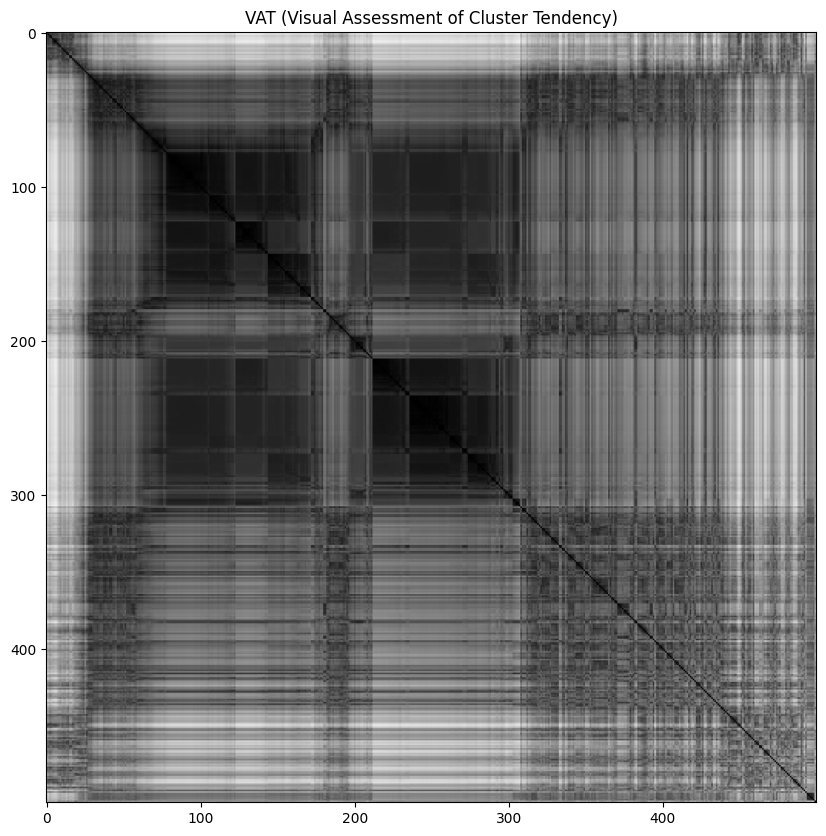

In [8]:
# Tomar una muestra representativa
np.random.seed(42)
n_muestras = 500
indices = np.random.choice(df_scaled.shape[0], n_muestras, replace=False)
muestra_tendencia = df_scaled.iloc[indices].values

# Calcular estadístico de Hopkins
h_score = hopkins(muestra_tendencia, n_muestras)
print(f"Estadístico de Hopkins: {h_score:.4f}")

# Visual Assessment of cluster Tendency (VAT)
plt.figure(figsize=(8, 8))
vat(muestra_tendencia)
plt.title("VAT (Visual Assessment of Cluster Tendency)")
plt.show()


**1.3 Número adecuado de grupos (Gráfica de Codo)** Mediante la suma de los errores al cuadrado (Inercia/WCSS), evaluaremos el quiebre de la curva (codo) para elegir .



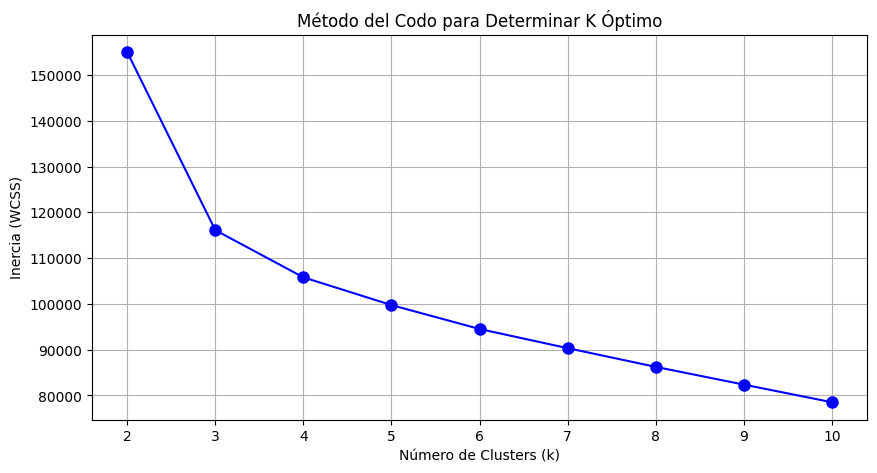

In [4]:
wcss = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, wcss, 'bo-', markersize=8)
plt.title('Método del Codo para Determinar K Óptimo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.grid(True)
plt.show()


**1.4 y 1.5 Aplicación de K-Medias, Jerárquico y Evaluación con Silueta**
Al identificar el codo (por ejemplo,  o ), aplicaremos los algoritmos y calcularemos el coeficiente de silueta. Tomaremos una muestra representativa en el cálculo de silueta para optimizar los tiempos de ejecución.



In [9]:
k_optimo = 3

# K-Means
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

# Clustering Jerárquico
hc = AgglomerativeClustering(n_clusters=k_optimo, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(df_scaled)

# Cálculo de la Silueta (Se usa sample_size para que corra eficientemente)
sil_kmeans = silhouette_score(df_scaled, kmeans_labels, sample_size=5000, random_state=42)
sil_hc = silhouette_score(df_scaled, hc_labels, sample_size=5000, random_state=42)

print(f"Calidad del modelo K-Means (Silueta): {sil_kmeans:.4f}")
print(f"Calidad del modelo Jerárquico (Silueta): {sil_hc:.4f}")

Calidad del modelo K-Means (Silueta): 0.3676
Calidad del modelo Jerárquico (Silueta): 0.3230



**1.6 Interpretación de los grupos** Uniremos las etiquetas obtenidas con el dataset original (sin escalar) para encontrar el sentido real de cada grupo (promedio de presupuesto, popularidad, duración, etc.).



Cluster,0,1,2
budget,12148.207900,4.149408e+07,4.588959e+06
revenue,16531.236486,1.139720e+08,7.668888e+06
runtime,27.655094,1.119802e+02,9.617613e+01
popularity,0.569403,4.673968e+01,2.711282e+01
voteAvg,0.926868,6.694807e+00,6.380771e+00
voteCount,0.985031,2.508617e+03,4.321279e+02
genresAmount,1.240125,2.817957e+00,2.450032e+00
productionCoAmount,0.657796,3.577842e+00,2.758392e+00
productionCountriesAmount,0.671622,1.406507e+00,1.397575e+00
actorsAmount,3.655717,4.138138e+01,1.972151e+01


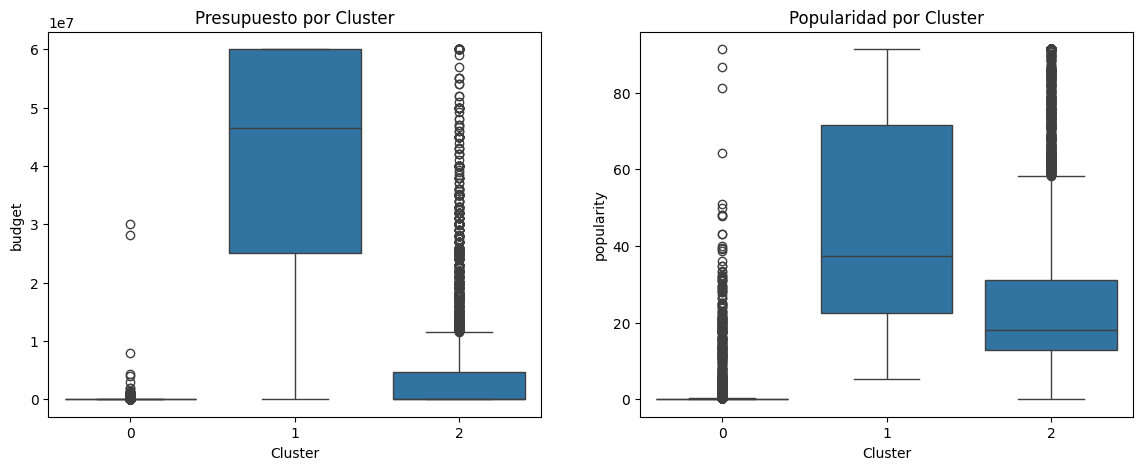

In [10]:
# Usar etiquetas de KMeans (el de mejor silueta) para la interpretación
df_clean['Cluster'] = kmeans_labels

# Resumen de Tendencia Central
resumen = df_clean.groupby('Cluster').mean().T
display(resumen)

# Gráfico para validar diferencias (ejemplo con Presupuesto y Revenue)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Cluster', y='budget', data=df_clean, ax=axes[0])
axes[0].set_title('Presupuesto por Cluster')

sns.boxplot(x='Cluster', y='popularity', data=df_clean, ax=axes[1])
axes[1].set_title('Popularidad por Cluster')
plt.show()


2. Reglas de Asociación
Usaremos el algoritmo "A priori". Se deben discretizar las variables numéricas importantes para transformarlas en categorías transaccionales de modo que tengan sentido al extraer insights.



In [15]:
# Escogemos variables influyentes
cols_reglas = ['budget', 'revenue', 'popularity', 'voteAvg', 'runtime']
df_reglas = df_clean[cols_reglas].copy()

# Discretizar en categorías cualitativas (Low, Medium, High) usando rank para evitar empates
for col in cols_reglas:
    # Aplicamos rank para desempatar valores idénticos (como los ceros)
    serie_rankeada = df_reglas[col].rank(method='first')

    # Ahora qcut puede dividir en 3 partes iguales sin que colapsen los bordes
    df_reglas[col] = pd.qcut(serie_rankeada, q=3, labels=['Bajo', 'Medio', 'Alto'])

    # Concatenar con el nombre de la variable para que Apriori no las confunda
    df_reglas[col] = df_reglas[col].astype(str) + '_' + col

# Convertir variables a formato dummy (One-Hot Encoding)
df_dummy = pd.get_dummies(df_reglas)

# Generación de ítems frecuentes (Soporte > 10%)
frequent_itemsets = apriori(df_dummy, min_support=0.10, use_colnames=True)

# Generar reglas de asociación (Confianza > 50%)
reglas = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.50)

# Ordenar por Lift (qué tan fuerte es la asociación) para ver las más interesantes primero
reglas = reglas.sort_values(by=['lift', 'confidence'], ascending=[False, False])

display(reglas.head(10))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
152,"(runtime_Alto_runtime, revenue_Alto_revenue)","(budget_Alto_budget, voteAvg_Alto_voteAvg)",0.212493,0.157220,0.107177,0.504379,3.208113,1.0,0.073769,1.700452,0.874012,0.408238,0.411921,0.593040
153,"(budget_Alto_budget, voteAvg_Alto_voteAvg)","(runtime_Alto_runtime, revenue_Alto_revenue)",0.157220,0.212493,0.107177,0.681702,3.208113,1.0,0.073769,2.474117,0.816690,0.408238,0.595815,0.593040
223,"(runtime_Bajo_runtime, budget_Bajo_budget, vot...","(revenue_Bajo_revenue, popularity_Bajo_popular...",0.186893,0.221295,0.128954,0.689989,3.117967,1.0,0.087596,2.511866,0.835411,0.461816,0.601890,0.636358
235,"(revenue_Bajo_revenue, popularity_Bajo_popular...","(runtime_Bajo_runtime, budget_Bajo_budget, vot...",0.221295,0.186893,0.128954,0.582727,3.117967,1.0,0.087596,1.948622,0.872317,0.461816,0.486817,0.636358
225,"(revenue_Bajo_revenue, runtime_Bajo_runtime, v...","(popularity_Bajo_popularity, budget_Bajo_budget)",0.190615,0.222200,0.128954,0.676517,3.044633,1.0,0.086600,2.404456,0.829708,0.454288,0.584105,0.628435
233,"(popularity_Bajo_popularity, budget_Bajo_budget)","(revenue_Bajo_revenue, runtime_Bajo_runtime, v...",0.222200,0.190615,0.128954,0.580353,3.044633,1.0,0.086600,1.928728,0.863401,0.454288,0.481524,0.628435
210,"(revenue_Bajo_revenue, popularity_Bajo_popular...","(runtime_Bajo_runtime, voteAvg_Bajo_voteAvg)",0.221295,0.226123,0.151436,0.684318,3.026312,1.0,0.101396,2.451447,0.859843,0.511640,0.592078,0.677012
215,"(runtime_Bajo_runtime, voteAvg_Bajo_voteAvg)","(revenue_Bajo_revenue, popularity_Bajo_popular...",0.226123,0.221295,0.151436,0.669706,3.026312,1.0,0.101396,2.357616,0.865208,0.511640,0.575843,0.677012
142,"(runtime_Alto_runtime, revenue_Alto_revenue)","(budget_Alto_budget, popularity_Alto_popularity)",0.212493,0.186038,0.119600,0.562840,3.025399,1.0,0.080068,1.861932,0.850107,0.428777,0.462923,0.602858
143,"(budget_Alto_budget, popularity_Alto_popularity)","(runtime_Alto_runtime, revenue_Alto_revenue)",0.186038,0.212493,0.119600,0.642876,3.025399,1.0,0.080068,2.205139,0.822477,0.428777,0.546514,0.602858



3. Análisis de Componentes Principales (PCA)


**3.1 Transformación de categóricas:**  Las variables categóricas puras (como texto y géneros) no deben incluirse en un PCA tradicional porque rompen con el supuesto de normalidad multivariada y relaciones lineales. Solo usaremos las variables numéricas estandarizadas.



**3.2 ¿Conviene aplicar PCA?:** Evaluamos si la estructura de correlaciones justifica el análisis utilizando los estadísticos de Kaiser-Meyer-Olkin (KMO) y de esfericidad de Bartlett.





In [13]:
# Quitamos el label de 'Cluster' añadido antes
df_pca_input = df_scaled.drop(columns=['Cluster'], errors='ignore')

# Esfericidad de Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(df_pca_input)
print(f"Prueba de Esfericidad de Bartlett: p-value = {p_value}")

# Índice KMO
kmo_all, kmo_model = calculate_kmo(df_pca_input)
print(f"Índice KMO global: {kmo_model:.4f}")


Prueba de Esfericidad de Bartlett: p-value = 0.0
Índice KMO global: 0.9138



**3.3 Análisis e Interpretación de los Componentes Principales**



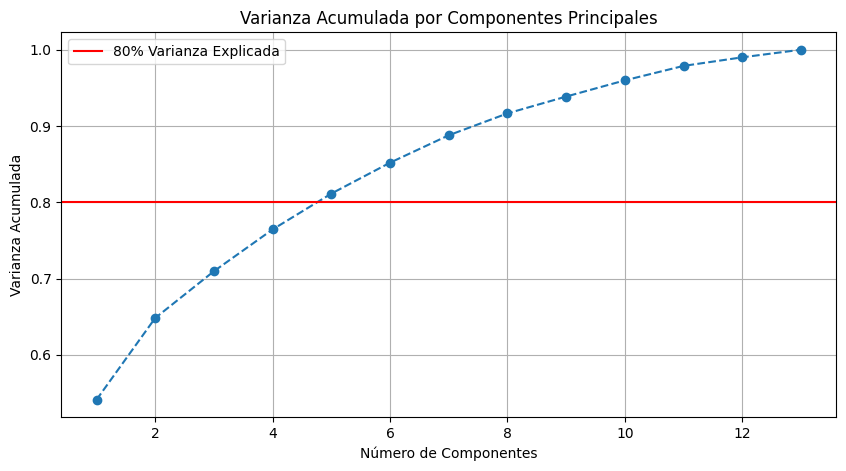

Se necesitan 5 componentes principales para explicar la variabilidad.


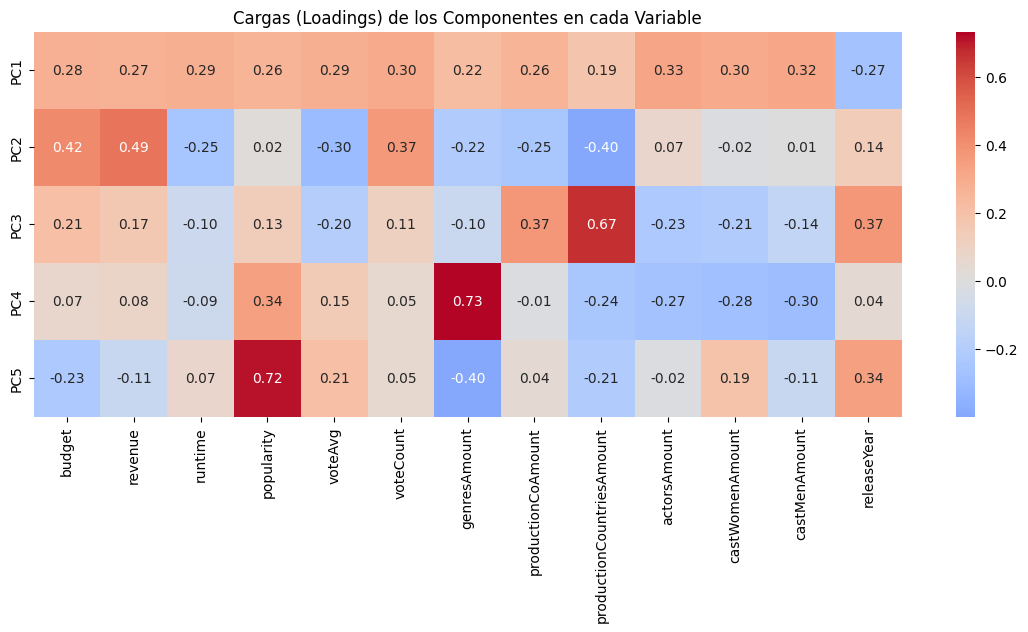

In [14]:
pca_test = PCA()
pca_test.fit(df_pca_input)

# Varianza acumulada
varianza_acumulada = np.cumsum(pca_test.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.80, color='r', linestyle='-', label='80% Varianza Explicada')
plt.title('Varianza Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.legend()
plt.grid()
plt.show()

# Seleccionamos componentes que expliquen al menos el 80% de variabilidad
n_comp = np.argmax(varianza_acumulada >= 0.80) + 1
print(f"Se necesitan {n_comp} componentes principales para explicar la variabilidad.")

# Aplicar PCA con los componentes seleccionados
pca_final = PCA(n_components=n_comp)
componentes = pca_final.fit_transform(df_pca_input)

# Interpretación (Cargas o Loadings)
pca_coef = pd.DataFrame(
    pca_final.components_,
    columns=df_pca_input.columns,
    index=[f'PC{i+1}' for i in range(n_comp)]
)

plt.figure(figsize=(14, n_comp))
sns.heatmap(pca_coef, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title('Cargas (Loadings) de los Componentes en cada Variable')
plt.show()